# Exploratory Data Analysis: Predicting Hard-Drive Failure from SMART Telemetry
**IST 707 – Applied Machine Learning · Final Project**

---

This notebook explores the modeling datasets (`modeling_train`, `modeling_calib`, `modeling_test`) used to
predict **whether a hard drive will fail** based on its SMART (Self-Monitoring, Analysis and Reporting
Technology) telemetry. It is organised as follows:

| § | Section | Purpose |
|---|---|---|
| 1 | Setup | Libraries, plotting style, helper functions |
| 2 | **Dataset provenance** | Where the data comes from, how it was built, size & features, *why we trust it* |
| 3 | Data quality audit | Missingness, keys, temporal integrity, physical plausibility |
| 4 | **Statistical Analysis 1** | Class imbalance and the train → test prior shift |
| 5 | **Statistical Analysis 2** | Who fails? Failure rates by manufacturer, model and drive age |
| 6 | **Statistical Analysis 3** | SMART signatures of failing vs healthy drives (hypothesis tests & effect sizes) |
| 7 | **Statistical Analysis 4** | Raw vs vendor-*normalized* SMART values: what normalization does to the signal |
| 8 | **Statistical Analysis 5** | Correlation, redundancy, degradation (deltas) and information ranking |
| 9 | Supplementary | Distribution drift between train (2023-24) and test (2025) |
| 10 | Conclusions | What we learned and how it shapes the modeling |

Every analysis opens with a short statement of **what it shows and why it matters**, and closes with an interpretation.

## 1. Setup

In [2]:
import warnings, os, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# ---- palette (colorblind-validated categorical order) ----
HEALTHY, FAILED = "#2a78d6", "#eb6834"          # class colours used everywhere
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SPLIT_COL = {"train": SERIES[0], "calib": SERIES[2], "test": SERIES[1]}
VENDOR_COL = {"Seagate": SERIES[0], "Toshiba": SERIES[1], "WDC": SERIES[2], "HGST": SERIES[6], "Other": "#9a9a96"}
DIVERGING = sns.blend_palette(["#184f95", "#f0efec", "#b52f2f"], as_cmap=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#8a8984",
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.7, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10.5, "axes.labelcolor": "#2b2b2a",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False, "font.size": 10,
    "lines.linewidth": 2,
})

DATA_DIR = "."
SPLITS = ["train", "calib", "test"]

SMART_IDS = [1, 3, 4, 5, 7, 9, 10, 12, 192, 193, 194, 197, 198, 199]
SMART_NAMES = {
    1: "Read Error Rate", 3: "Spin-Up Time", 4: "Start/Stop Count", 5: "Reallocated Sectors",
    7: "Seek Error Rate", 9: "Power-On Hours", 10: "Spin Retry Count", 12: "Power Cycle Count",
    192: "Power-Off Retract Count", 193: "Load/Unload Cycles", 194: "Temperature (°C)",
    197: "Current Pending Sectors", 198: "Offline Uncorrectable", 199: "UltraDMA CRC Errors",
}
def sname(i): return f"S{i} {SMART_NAMES[i]}"

def vendor(model: str) -> str:
    m = str(model)
    if m.startswith("ST"): return "Seagate"
    if m.startswith("TOSHIBA"): return "Toshiba"
    if m.startswith(("WDC", "WUH")): return "WDC"
    if m.startswith(("HGST", "Hitachi")): return "HGST"
    return "Other"

def wilson(k, n, z=1.96):
    # Wilson score interval for a binomial proportion
    k, n = np.asarray(k, float), np.asarray(n, float)
    p = k / n
    den = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return p, centre - half, centre + half

def oriented_auc(y, x):
    # AUC with direction removed: 0.5 = no signal, 1.0 = perfect separation
    m = ~np.isnan(x)
    if np.unique(x[m]).size < 2: return 0.5
    a = roc_auc_score(y[m], x[m])
    return max(a, 1 - a)

def pct(x, d=2): return f"{100*x:.{d}f}%"
print("Libraries loaded.")

Libraries loaded.


### 1.1 Loading the data
`modeling_train` and `modeling_calib` are small enough to load in full. `modeling_test` has **3.5 million rows**,
so we load only the columns needed for each analysis. This keeps memory manageable without dropping any rows.

In [ ]:

train = pd.read_parquet("modeling_train.parquet")
calib = pd.read_parquet("modeling_calib.parquet")

KEY_RAW  = [f"smart_{i}_raw_last" for i in SMART_IDS]
KEY_NORM = [f"smart_{i}_normalized_last" for i in SMART_IDS]
META = ["serial_number", "window", "window_first_date", "window_last_date", "days_observed",
        "days_span", "capacity_bytes", "model", "label", "drive_days_to_date"]
test = pd.read_parquet("modeling_test.parquet",
                       columns=META + KEY_RAW + KEY_NORM + ["smart_5_raw_delta", "smart_197_raw_delta", "smart_198_raw_delta"])

for name, df in [("train", train), ("calib", calib), ("test", test)]:
    df["vendor"] = df["model"].map(vendor)
    df["capacity_tb"] = (df["capacity_bytes"] / 1e12).round(0)
    df["age_years"] = df["smart_9_raw_last"] / (24 * 365.25)

DFS = {"train": train, "calib": calib, "test": test}

for k, d in DFS.items():
    print(f"{k:>5}: {d.shape[0]:>10,} rows × {d.shape[1]:>3} cols loaded   |  {d.memory_usage(deep=True).sum()/1e6:,.0f} MB in memory")

train:    169,827 rows ×  97 cols loaded   |  106 MB in memory
calib:    297,009 rows ×  97 cols loaded   |  185 MB in memory
 test:  3,521,973 rows ×  44 cols loaded   |  1,095 MB in memory


## 2. Dataset Provenance

### 2.1 Where the data came from

todo

### 2.2 Size and features

In [5]:
sizes = []
for k in SPLITS:
    d = DFS[k]
    sizes.append({
        "split": k,
        "file size (MB)": os.path.getsize(f"{DATA_DIR}/modeling_{k}.parquet") / 1e6,
        "rows (drive-windows)": len(d),
        "columns in file": 94,
        "unique drives": d["serial_number"].nunique(),
        "drive models": d["model"].nunique(),
        "failures (label=1)": int(d["label"].sum()),
        "failure rate": d["label"].mean(),
        "first date": d["window_first_date"].min().date(),
        "last date": d["window_last_date"].max().date(),
        "windows": f'{d["window"].min()}–{d["window"].max()}',
    })
sizes = pd.DataFrame(sizes).set_index("split")
display(sizes.style.format({"file size (MB)": "{:,.1f}", "rows (drive-windows)": "{:,}", "unique drives": "{:,}",
                            "failures (label=1)": "{:,}", "failure rate": "{:.3%}"}))
total = sizes["rows (drive-windows)"].sum()
print(f"Total: {total:,} drive-windows ≈ {total*30/1e6:,.0f} million drive-days of telemetry")

,file size (MB),rows (drive-windows),columns in file,unique drives,drive models,failures (label=1),failure rate,first date,last date,windows
split,,,,,,,,,,
train,9.0,"169,827",94,"131,815",63,"8,087",4.762%,2023-01-01,2024-10-21,0–21
calib,13.0,"297,009",94,"293,236",55,328,0.110%,2024-11-01,2024-12-20,22–23
test,141.4,"3,521,973",94,"344,023",59,"3,722",0.106%,2025-01-01,2025-12-15,24–35


Total: 3,988,809 drive-windows ≈ 120 million drive-days of telemetry


In [6]:
# Feature catalogue: 94 columns in 6 families
fam = []
for c in train.columns:
    if c in ("vendor", "capacity_tb", "age_years"): continue
    if c.startswith("smart_"):
        parts = c.split("_"); i = int(parts[1]); kind = parts[2]; stat = parts[3]
        fam.append((f"SMART {kind} · {stat}", c, str(train[c].dtype)))
    else:
        fam.append(("identifier / metadata" if c not in ("label",) else "target", c, str(train[c].dtype)))
fam = pd.DataFrame(fam, columns=["family", "column", "dtype"])
summary = fam.groupby("family").agg(n_columns=("column", "size"), example=("column", "first"), dtype=("dtype", "first"))
display(summary)

,n_columns,example,dtype
family,,,
SMART normalized · delta,14,smart_10_normalized_delta,float32
SMART normalized · first,14,smart_10_normalized_first,float32
SMART normalized · last,14,smart_10_normalized_last,float32
SMART raw · delta,14,smart_10_raw_delta,float64
SMART raw · first,14,smart_10_raw_first,float64
SMART raw · last,14,smart_10_raw_last,float64
identifier / metadata,9,serial_number,string
target,1,label,int8


**SMART attribute dictionary.** For each attribute we have a *raw* value and a *normalized* value. The raw value is
usually a physical count (sectors, hours, °C, events). The normalized value is a score the vendor computes inside the
drive firmware, usually on a 1–253 scale. It starts at 100 or 200 and counts **down** as the drive's health gets worse.

| ID | Attribute | Raw unit | Why it matters for failure |
todo

### 2.3 Why we trust this data
todo

In [7]:
checks = []
def chk(name, ok, detail): checks.append({"check": name, "result": "PASS" if ok else "REVIEW", "evidence": detail})

for k in SPLITS:
    d = DFS[k]
    dup = d.duplicated(["serial_number", "window"]).sum()
    chk(f"[{k}] (serial, window) is a unique key", dup == 0, f"{dup} duplicate keys")

chk("Splits are temporally disjoint (train < calib < test)",
    train.window_last_date.max() < calib.window_first_date.min() <= calib.window_last_date.max() < test.window_first_date.min(),
    f"train ends {train.window_last_date.max().date()}, calib {calib.window_first_date.min().date()}→{calib.window_last_date.max().date()}, test starts {test.window_first_date.min().date()}")

ratio = (train.label == 0).sum() / (train.label == 1).sum()
chk("Train negatives were down-sampled at a fixed 20:1 ratio", abs(ratio - 20) < 1e-9, f"neg/pos = {ratio:.4f}")

for k in SPLITS:
    d = DFS[k]
    last_w = d.groupby("serial_number")["window"].transform("max")
    p = d.label == 1
    share = (d.loc[p, "window"] == last_w[p]).mean()
    multi = d.loc[p, "serial_number"].duplicated().sum()
    chk(f"[{k}] A failure is the drive's final window", share > 0.995, f"{share:.4%} of failures are the last window; {multi} drives fail twice")

t_lo, t_hi = train.smart_194_raw_last.min(), train.smart_194_raw_last.max()
chk("Temperature (S194 raw) is physically plausible", 5 <= t_lo and t_hi <= 70, f"range {t_lo:.0f}–{t_hi:.0f} °C")

full = train[(train.days_span == 29)]
poh_ratio = (full.smart_9_raw_delta / (full.days_span * 24)).median()
chk("Power-on-hour delta matches calendar time (≈24 h/day)", 0.95 < poh_ratio < 1.05, f"median ΔPOH / (24·Δdays) = {poh_ratio:.3f}")

miss = train.isna().mean().max()
chk("Missingness is low", miss < 0.05, f"worst column {train.isna().mean().idxmax()} = {miss:.2%} missing")

neg_raw = (train[[c for c in train.columns if c.endswith(('_raw_last', '_raw_first'))]] < 0).sum().sum()
chk("Raw counters are non-negative", neg_raw == 0, f"{neg_raw} negative raw values")

display(pd.DataFrame(checks).style.map(lambda v: "color:#008300;font-weight:bold" if v == "PASS" else "color:#b52f2f;font-weight:bold", subset=["result"]))

,check,result,evidence
0,"[train] (serial, window) is a unique key",PASS,0 duplicate keys
1,"[calib] (serial, window) is a unique key",PASS,0 duplicate keys
2,"[test] (serial, window) is a unique key",PASS,0 duplicate keys
3,Splits are temporally disjoint (train < calib < test),PASS,"train ends 2024-10-21, calib 2024-11-01→2024-12-20, test starts 2025-01-01"
4,Train negatives were down-sampled at a fixed 20:1 ratio,PASS,neg/pos = 20.0000
5,[train] A failure is the drive's final window,PASS,99.9629% of failures are the last window; 1 drives fail twice
6,[calib] A failure is the drive's final window,PASS,100.0000% of failures are the last window; 0 drives fail twice
7,[test] A failure is the drive's final window,PASS,99.5701% of failures are the last window; 0 drives fail twice
8,Temperature (S194 raw) is physically plausible,PASS,range 13–59 °C
9,Power-on-hour delta matches calendar time (≈24 h/day),PASS,median ΔPOH / (24·Δdays) = 1.000


**Interpretation: the audit passes on every check.**
todo

## 3. Data Quality Audit

### 3.1 Missing values
todo

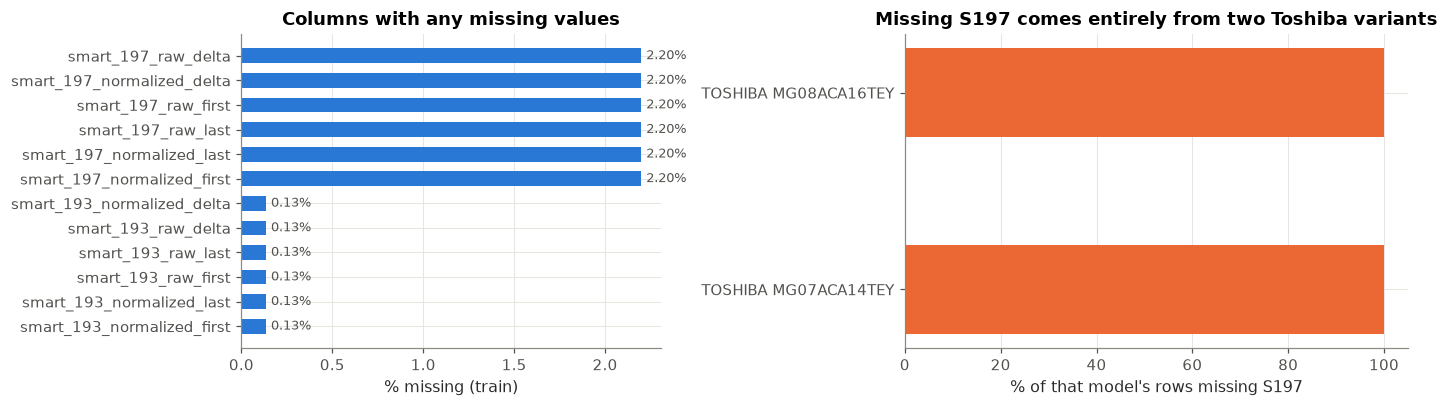

,S197 missing,S197 % missing,S193 missing,S193 % missing
model,,,,
TOSHIBA MG08ACA16TEY,3397,100.0%,0,0.0%
TOSHIBA MG07ACA14TEY,333,100.0%,0,0.0%
ST500LM012 HN,0,0.0%,225,100.0%


In [8]:
na = train.isna().mean()
na = na[na > 0].sort_values()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 1.2]})
axes[0].barh(na.index, na.values * 100, color=SERIES[0], height=0.6)
axes[0].set_xlabel("% missing (train)"); axes[0].set_title("Columns with any missing values")
for y, v in enumerate(na.values * 100): axes[0].text(v + 0.03, y, f"{v:.2f}%", va="center", fontsize=8.5, color="#52514e")

miss_by_model = (train.assign(m197=train.smart_197_raw_last.isna(), m193=train.smart_193_raw_last.isna())
                 .groupby("model")[["m197", "m193"]].agg(["sum", "mean"]))
miss_by_model.columns = ["S197 missing", "S197 % missing", "S193 missing", "S193 % missing"]
top = miss_by_model[miss_by_model["S197 missing"] > 0].sort_values("S197 missing", ascending=False)
axes[1].barh(top.index[::-1], top["S197 % missing"][::-1] * 100, color=SERIES[1], height=0.45)
axes[1].set_xlabel("% of that model's rows missing S197"); axes[1].set_title("Missing S197 comes entirely from two Toshiba variants")
plt.tight_layout(); plt.show()
display(miss_by_model[(miss_by_model["S197 missing"] > 0) | (miss_by_model["S193 missing"] > 0)]
        .sort_values("S197 missing", ascending=False).head(10)
        .style.format({"S197 % missing": "{:.1%}", "S193 % missing": "{:.1%}"}))

**Interpretation.** todo

### 3.2 Coverage over time and drive overlap between splits
**What this shows:** todo

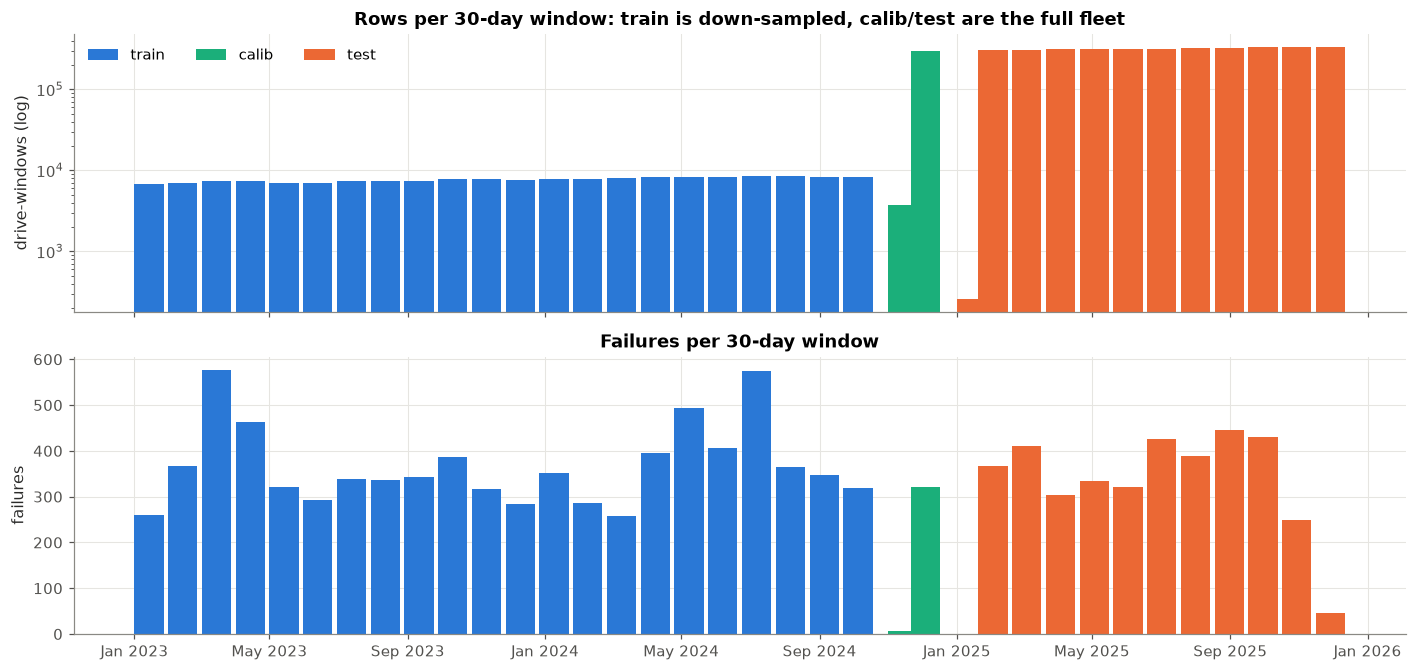

,train ∩ calib,train ∩ test,calib ∩ test,test drives never seen in train,share of test drives seen in train
unique serials,"113,373","113,178","292,547","230,845",32.9%


In [9]:
cov = pd.concat([d.groupby("window").agg(rows=("label", "size"), failures=("label", "sum"),
                                         start=("window_first_date", "min")).assign(split=k)
                 for k, d in DFS.items()]).reset_index()
fig, axes = plt.subplots(2, 1, figsize=(13, 6.2), sharex=True)
for k in SPLITS:
    c = cov[cov.split == k]
    axes[0].bar(c.start, c.rows, width=26, color=SPLIT_COL[k], label=k, align="edge")
    axes[1].bar(c.start, c.failures, width=26, color=SPLIT_COL[k], label=k, align="edge")
axes[0].set_yscale("log"); axes[0].set_ylabel("drive-windows (log)")
axes[0].set_title("Rows per 30-day window: train is down-sampled, calib/test are the full fleet")
axes[0].legend(ncol=3, loc="upper left")
axes[1].set_ylabel("failures"); axes[1].set_title("Failures per 30-day window")
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.tight_layout(); plt.show()

s = {k: set(d.serial_number.unique()) for k, d in DFS.items()}
ov = pd.DataFrame({
    "train ∩ calib": [len(s["train"] & s["calib"])],
    "train ∩ test": [len(s["train"] & s["test"])],
    "calib ∩ test": [len(s["calib"] & s["test"])],
    "test drives never seen in train": [len(s["test"] - s["train"])],
    "share of test drives seen in train": [len(s["test"] & s["train"]) / len(s["test"])],
}, index=["unique serials"])
display(ov.style.format({c: "{:,}" for c in ov.columns[:-1]} | {"share of test drives seen in train": "{:.1%}"}))

**Interpretation.** todo

---
## 4. Statistical Analysis 1: Class Imbalance and the Train → Test Prior Shift

**What this shows:** todo

In [11]:
rows = []
for k in SPLITS:
    d = DFS[k]; n, kpos = len(d), int(d.label.sum())
    p, lo, hi = wilson(kpos, n)
    rows.append({"split": k, "n": n, "failures": kpos, "failure rate": p, "95% CI low": lo, "95% CI high": hi,
                 "imbalance (neg:pos)": f"{(n-kpos)/kpos:,.0f} : 1"})
imb = pd.DataFrame(rows).set_index("split")



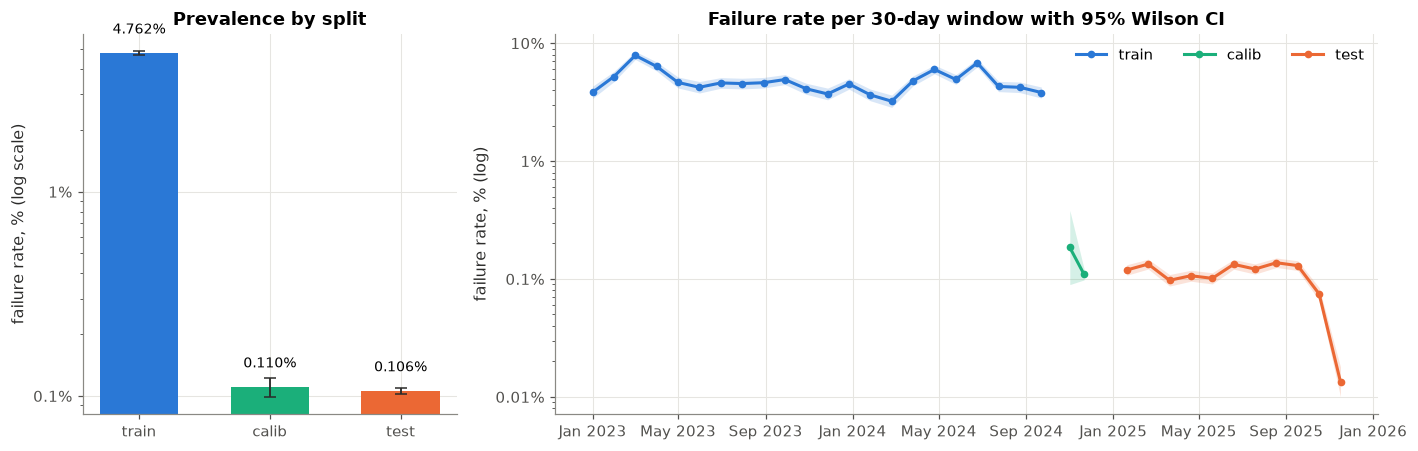

Test: χ² homogeneity of failure rate across 11 windows: χ²=411.2, dof=10, p=3.89e-82
      excluding the final (right-censored) window: χ²=103.0, dof=9, p=3.89e-18


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 2.2]})
ax = axes[0]
x = np.arange(3)
ax.bar(x, imb["failure rate"] * 100, color=[SPLIT_COL[k] for k in SPLITS], width=0.6)
ax.errorbar(x, imb["failure rate"] * 100, yerr=[(imb["failure rate"] - imb["95% CI low"]) * 100, (imb["95% CI high"] - imb["failure rate"]) * 100],
            fmt="none", ecolor="#2b2b2a", capsize=4, lw=1.2)
ax.set_yscale("log"); ax.set_xticks(x, SPLITS); ax.set_ylabel("failure rate, % (log scale)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}%"))
for xi, v in zip(x, imb["failure rate"] * 100): ax.text(xi, v * 1.25, f"{v:.3f}%", ha="center", fontsize=9)
ax.set_title("Prevalence by split")

ax = axes[1]
for k in SPLITS:
    g = DFS[k].groupby("window").agg(n=("label", "size"), k=("label", "sum"), t=("window_first_date", "min"))
    g = g[g.n > 1000]
    p, lo, hi = wilson(g.k, g.n)
    ax.plot(g.t, p * 100, "-o", ms=4, color=SPLIT_COL[k], label=k)
    ax.fill_between(g.t, lo * 100, hi * 100, color=SPLIT_COL[k], alpha=0.18, lw=0)
ax.set_yscale("log"); ax.set_ylabel("failure rate, % (log)"); ax.legend(ncol=3)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}%"))
ax.set_title("Failure rate per 30-day window with 95% Wilson CI")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.tight_layout(); plt.show()

# Is the monthly failure rate stable within test? Chi-square test of homogeneity across windows
g = test.groupby("window").label.agg(["sum", "size"]); g = g[g["size"] > 1000]
chi2, pval, dof, _ = stats.chi2_contingency(np.c_[g["sum"], g["size"] - g["sum"]])
print(f"Test: χ² homogeneity of failure rate across {len(g)} windows: χ²={chi2:.1f}, dof={dof}, p={pval:.2e}")
g2 = g.iloc[:-1]
chi2b, pvalb, dofb, _ = stats.chi2_contingency(np.c_[g2["sum"], g2["size"] - g2["sum"]])
print(f"      excluding the final (right-censored) window: χ²={chi2b:.1f}, dof={dofb}, p={pvalb:.2e}")

**Interpretation.**
todo

---
## 5. Statistical Analysis 2: Who Fails? Manufacturer, Model and Age

**What this shows:** 
todo

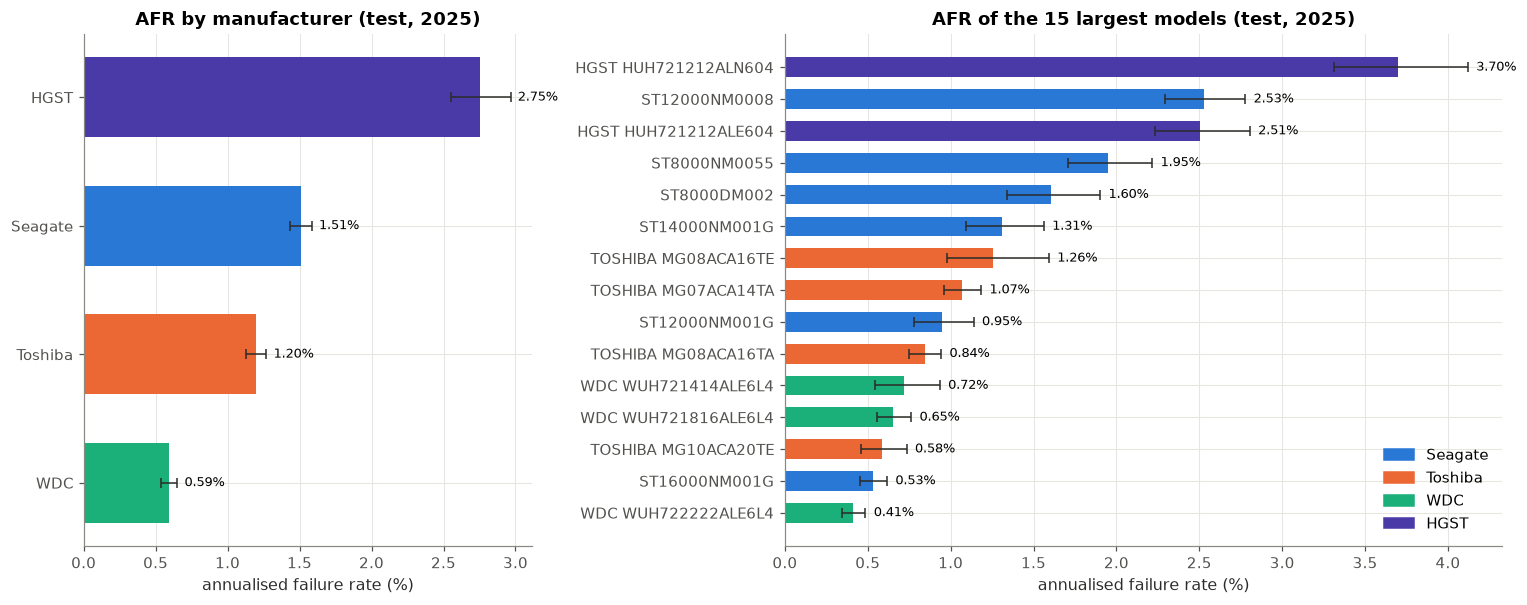

,drives,failures,drive_years,AFR,AFR_lo,AFR_hi
vendor,,,,,,
WDC,"84,369",404,"68,486",0.59%,0.53%,0.65%
Toshiba,"114,034","1,130","94,372",1.20%,1.13%,1.27%
Seagate,"113,682","1,499","99,501",1.51%,1.43%,1.58%
HGST,"31,938",689,"25,033",2.75%,2.55%,2.97%


In [13]:
def afr_table(d, by):
    g = d.groupby(by).agg(failures=("label", "sum"), drive_days=("days_observed", "sum"), drives=("serial_number", "nunique"))
    g["drive_years"] = g.drive_days / 365
    g["AFR"] = g.failures / g.drive_years
    # exact Poisson CI for the failure count
    g["AFR_lo"] = stats.chi2.ppf(0.025, 2 * g.failures) / 2 / g.drive_years
    g["AFR_hi"] = stats.chi2.ppf(0.975, 2 * (g.failures + 1)) / 2 / g.drive_years
    return g.fillna(0)

afr_v = afr_table(test, "vendor").sort_values("AFR")
afr_m = afr_table(test, "model").sort_values("drive_years", ascending=False).head(15).sort_values("AFR")
afr_m["vendor"] = afr_m.index.map(vendor)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1, 1.6]})
for ax, t, title in [(axes[0], afr_v, "AFR by manufacturer (test, 2025)"), (axes[1], afr_m, "AFR of the 15 largest models (test, 2025)")]:
    cols = [VENDOR_COL[v] for v in (t.index if t is afr_v else t.vendor)]
    y = np.arange(len(t))
    ax.barh(y, t.AFR * 100, color=cols, height=0.62)
    ax.errorbar(t.AFR * 100, y, xerr=[(t.AFR - t.AFR_lo) * 100, (t.AFR_hi - t.AFR) * 100], fmt="none", ecolor="#2b2b2a", capsize=3, lw=1)
    ax.set_yticks(y, t.index); ax.set_xlabel("annualised failure rate (%)"); ax.set_title(title)
    for yi, (v, hi) in enumerate(zip(t.AFR * 100, t.AFR_hi * 100)): ax.text(hi + 0.05, yi, f"{v:.2f}%", va="center", fontsize=8.5)
handles = [plt.Rectangle((0, 0), 1, 1, color=VENDOR_COL[v]) for v in ["Seagate", "Toshiba", "WDC", "HGST"]]
axes[1].legend(handles, ["Seagate", "Toshiba", "WDC", "HGST"], loc="lower right")
plt.tight_layout(); plt.show()

display(afr_v[["drives", "failures", "drive_years", "AFR", "AFR_lo", "AFR_hi"]]
        .style.format({"drives": "{:,}", "failures": "{:,}", "drive_years": "{:,.0f}", "AFR": "{:.2%}", "AFR_lo": "{:.2%}", "AFR_hi": "{:.2%}"}))



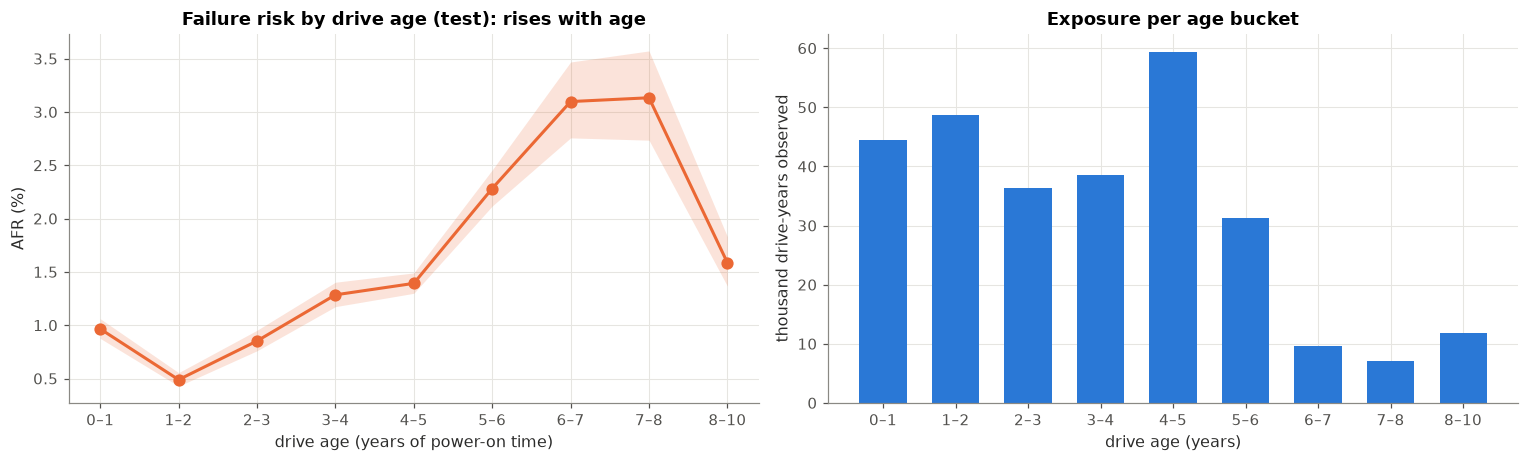

,drives,failures,AFR,AFR_lo,AFR_hi
capacity (TB),,,,,
8,"24,041",402,1.87%,1.69%,2.06%
12,"60,901","1,238",2.29%,2.16%,2.42%
14,"59,786",620,1.16%,1.07%,1.26%
16,"117,124","1,048",1.01%,0.95%,1.07%
20,"18,072",72,0.58%,0.46%,0.73%
22,"44,537",139,0.41%,0.35%,0.49%
24,"12,140",146,2.56%,2.16%,3.01%


In [14]:
# Failure risk vs age (power-on hours → years)
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 14]
d = test.dropna(subset=["age_years"]).copy()
d["age_bin"] = pd.cut(d.age_years, bins, right=False)
age = afr_table(d, "age_bin")
age = age[age.drive_years > 500]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
ax = axes[0]
xl = [f"{int(i.left)}–{int(i.right)}" for i in age.index]
ax.plot(xl, age.AFR * 100, "-o", color=FAILED, ms=7)
ax.fill_between(xl, age.AFR_lo * 100, age.AFR_hi * 100, color=FAILED, alpha=0.18, lw=0)
ax.set_xlabel("drive age (years of power-on time)"); ax.set_ylabel("AFR (%)")
ax.set_title("Failure risk by drive age (test): rises with age")
ax2 = axes[1]
ax2.bar(xl, age.drive_years / 1e3, color=HEALTHY, width=0.65)
ax2.set_xlabel("drive age (years)"); ax2.set_ylabel("thousand drive-years observed"); ax2.set_title("Exposure per age bucket")
plt.tight_layout(); plt.show()


# Capacity
cap = afr_table(test, "capacity_tb"); cap = cap[cap.drive_years > 1000]
cap.index = cap.index.astype(int)
display(cap[["drives", "failures", "AFR", "AFR_lo", "AFR_hi"]].rename_axis("capacity (TB)")
        .style.format({"drives": "{:,}", "failures": "{:,}", "AFR": "{:.2%}", "AFR_lo": "{:.2%}", "AFR_hi": "{:.2%}"}))

**Interpretation.**
todo

---
## 6. Statistical Analysis 3: SMART Signatures of Failing vs Healthy Drives

todo

In [22]:
y = train.label.values
res = []
for i in SMART_IDS:
    c = f"smart_{i}_raw_last"
    x = train[c].values.astype(float); m = ~np.isnan(x)
    xf, xh = x[m & (y == 1)], x[m & (y == 0)]
    nz_f, nz_h = (xf > 0).mean(), (xh > 0).mean()
    # odds ratio of failure given non-zero (Haldane-Anscombe correction)
    a, b = (xf > 0).sum() + .5, (xf == 0).sum() + .5
    c_, d_ = (xh > 0).sum() + .5, (xh == 0).sum() + .5
    OR = (a * d_) / (b * c_); se = np.sqrt(1/a + 1/b + 1/c_ + 1/d_)
    U, p_mw = stats.mannwhitneyu(xf, xh, alternative="two-sided")
    delta = 2 * U / (len(xf) * len(xh)) - 1
    D, p_ks = stats.ks_2samp(xf, xh)
    res.append({"attribute": sname(i), "median healthy": np.median(xh), "median failed": np.median(xf),
                "% non-zero healthy": nz_h, "% non-zero failed": nz_f,
                "odds ratio (non-zero)": OR, "OR 95% CI": f"{np.exp(np.log(OR)-1.96*se):.1f}–{np.exp(np.log(OR)+1.96*se):.1f}",
                "Cliff's δ": delta, "KS D": D, "Mann-Whitney p": p_mw})
sig = pd.DataFrame(res).set_index("attribute").sort_values("KS D", ascending=False)
# Bonferroni across 14 tests
sig["significant (Bonferroni α=.05/14)"] = sig["Mann-Whitney p"] < 0.05 / len(SMART_IDS)
def mag(dl): a = abs(dl); return "negligible" if a < .147 else "small" if a < .33 else "medium" if a < .474 else "large"
sig["effect"] = sig["Cliff's δ"].map(mag)
# an odds ratio for "non-zero" is meaningless for counters that are (almost) always non-zero
always = sig["% non-zero healthy"] > 0.95
sig.loc[always, "odds ratio (non-zero)"] = np.nan; sig.loc[always, "OR 95% CI"] = "n/a (always > 0)"
display(sig.style.format({"median healthy": "{:,.0f}", "median failed": "{:,.0f}", "% non-zero healthy": "{:.1%}", "% non-zero failed": "{:.1%}",
                          "odds ratio (non-zero)": lambda v: "n/a" if pd.isna(v) else f"{v:,.2f}", "Cliff's δ": "{:+.3f}", "KS D": "{:.3f}", "Mann-Whitney p": "{:.1e}"})
        .background_gradient(subset=["KS D"], cmap="Blues"))

,median healthy,median failed,% non-zero healthy,% non-zero failed,odds ratio (non-zero),OR 95% CI,Cliff's δ,KS D,Mann-Whitney p,significant (Bonferroni α=.05/14),effect
attribute,,,,,,,,,,,
S5 Reallocated Sectors,0,0,3.4%,47.9%,25.92,24.6–27.3,+0.451,0.444,0.0e+00,True,medium
S197 Current Pending Sectors,0,0,1.2%,41.5%,59.02,55.4–62.9,+0.405,0.403,0.0e+00,True,medium
S198 Offline Uncorrectable,0,0,0.8%,30.9%,55.95,52.0–60.2,+0.302,0.301,0.0e+00,True,small
S9 Power-On Hours,"25,125","33,996",100.0%,100.0%,n/a,n/a (always > 0),+0.263,0.236,0.0e+00,True,small
S193 Load/Unload Cycles,"1,187","1,800",100.0%,100.0%,n/a,n/a (always > 0),+0.205,0.199,9.0e-212,True,small
S4 Start/Stop Count,9,12,100.0%,100.0%,n/a,n/a (always > 0),+0.232,0.158,8.0e-274,True,small
S3 Spin-Up Time,149,0,50.4%,35.3%,0.54,0.5–0.6,-0.144,0.154,1.2e-121,True,negligible
S1 Read Error Rate,0,"23,744,184",42.1%,57.3%,1.84,1.8–1.9,+0.143,0.151,8.6e-129,True,negligible
S12 Power Cycle Count,9,12,100.0%,100.0%,n/a,n/a (always > 0),+0.219,0.149,1.6e-244,True,small


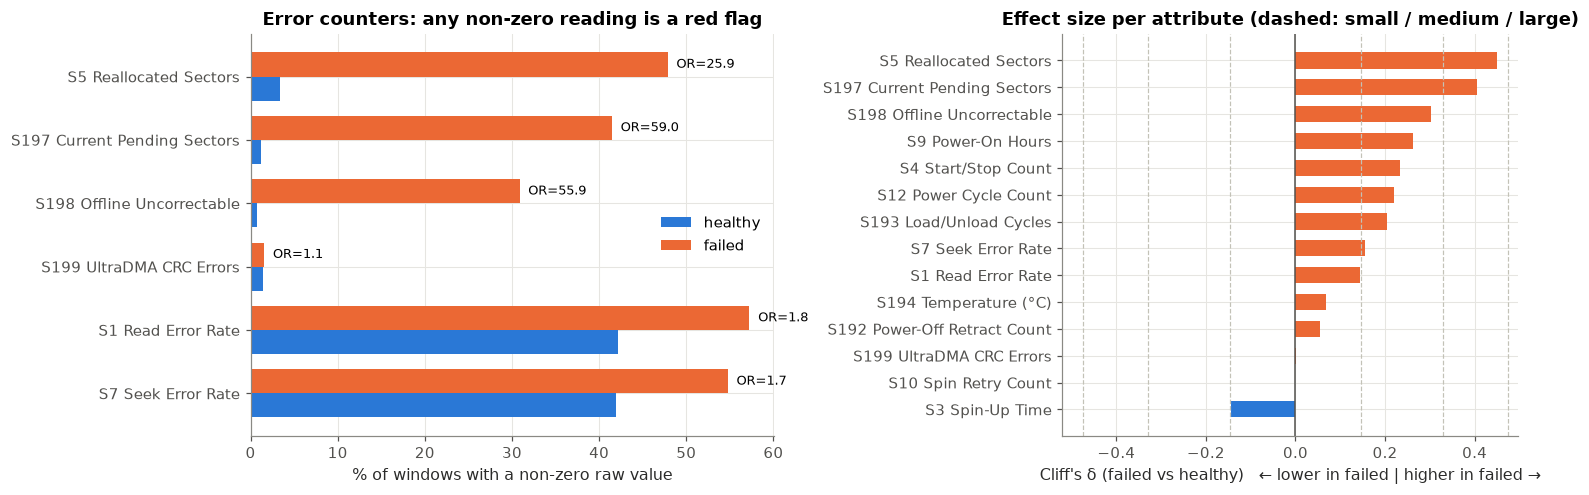

In [23]:
ERR = [5, 197, 198, 199, 1, 7]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
labels = [sname(i) for i in ERR]
yy = np.arange(len(ERR)); h = 0.38
ax.barh(yy + h/2, sig.loc[labels, "% non-zero healthy"] * 100, h, color=HEALTHY, label="healthy")
ax.barh(yy - h/2, sig.loc[labels, "% non-zero failed"] * 100, h, color=FAILED, label="failed")
for yi, lab in zip(yy, labels):
    ax.text(sig.loc[lab, "% non-zero failed"] * 100 + 1, yi - h/2, f'OR={sig.loc[lab, "odds ratio (non-zero)"]:.1f}', va="center", fontsize=8.5)
ax.set_yticks(yy, labels); ax.invert_yaxis(); ax.set_xlabel("% of windows with a non-zero raw value")
ax.set_title("Error counters: any non-zero reading is a red flag"); ax.legend(loc="center right")

ax = axes[1]
order = sig.sort_values("Cliff's δ").index
cols = [FAILED if v > 0 else HEALTHY for v in sig.loc[order, "Cliff's δ"]]
ax.barh(order, sig.loc[order, "Cliff's δ"], color=cols, height=0.6)
for t in (-.474, -.33, -.147, .147, .33, .474): ax.axvline(t, color="#c3c2b7", lw=0.8, ls="--")
ax.axvline(0, color="#52514e", lw=1)
ax.set_xlabel("Cliff's δ (failed vs healthy)   ← lower in failed | higher in failed →")
ax.set_title("Effect size per attribute (dashed: small / medium / large)")
plt.tight_layout(); plt.show()

In [ ]:
# Distribution shape for the three strongest precursors: ECDF on log scale (non-zero part) + P(fail | value bucket)
fig, axes = plt.subplots(2, 3, figsize=(15, 7.4))
for j, i in enumerate([5, 197, 198]):
    c = f"smart_{i}_raw_last"
    ax = axes[0, j]
    for lab, col, nm in [(0, HEALTHY, "healthy"), (1, FAILED, "failed")]:
        v = train.loc[(train.label == lab) & (train[c] > 0), c].sort_values()
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=col, label=f"{nm} (n={len(v):,})")
    ax.set_xscale("log"); ax.set_title(f"{sname(i)} · ECDF (non-zero)", fontsize=10.5); ax.set_xlabel("raw value (log)"); ax.set_ylabel("cumulative share")
    ax.legend(loc="lower right", fontsize=8.5)

    ax = axes[1, j]
    bucket = pd.cut(train[c], [-0.5, 0.5, 1.5, 8.5, 64.5, 512.5, np.inf], labels=["0", "1", "2–8", "9–64", "65–512", ">512"])
    g = train.groupby(bucket, observed=True).label.agg(["sum", "size"])
    # convert back to natural prevalence by re-weighting negatives ×20
    nat = g["sum"] / (g["sum"] + 20 * (g["size"] - g["sum"]))
    ax.bar(g.index.astype(str), nat * 100, color=FAILED, width=0.65)
    for xi, (v, n) in enumerate(zip(nat * 100, g["size"])): ax.text(xi, v, f"{v:.1f}%\nn={n:,}", ha="center", va="bottom", fontsize=7.5)
    ax.set_ylabel("est. failure probability per window (%)"); ax.set_xlabel(f"{sname(i)} raw value")
    ax.set_title("Failure risk rises with the count"); ax.set_ylim(0, nat.max() * 100 * 1.3)
plt.tight_layout(); plt.show()

---
## 7. Statistical Analysis 3: Raw vs Normalized SMART Values (What Normalization Does)

todo

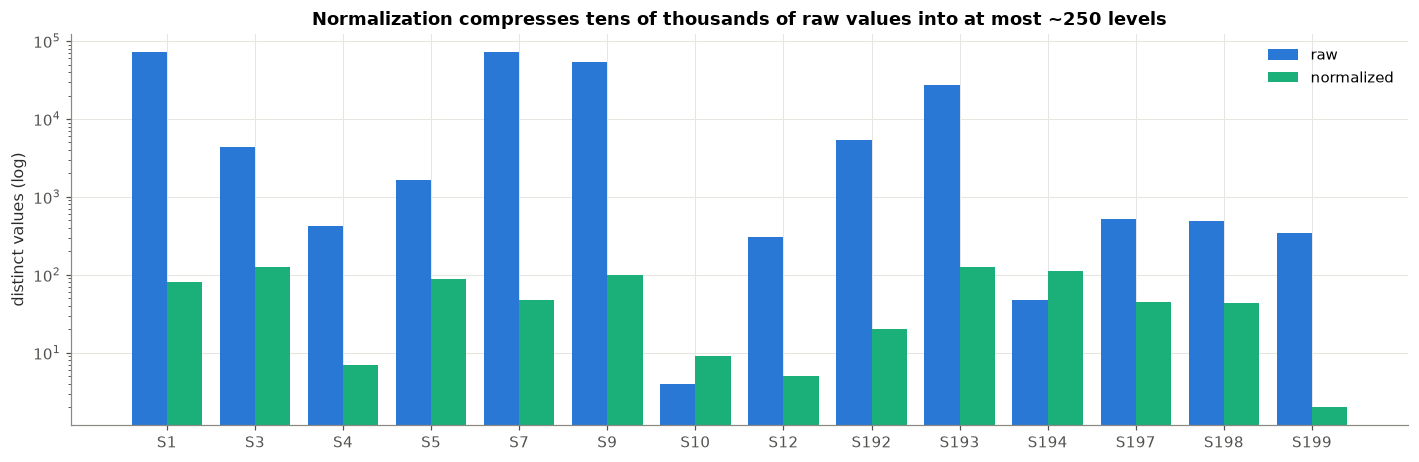

,distinct raw,distinct normalized,raw: share at mode,normalized: share at mode,normalized range,compression (raw/normalized)
attribute,,,,,,
S1 Read Error Rate,"72,495",80,57.1%,57.7%,1–200,906×
S3 Spin-Up Time,"4,432",127,50.3%,36.6%,80–253,35×
S4 Start/Stop Count,420,7,7.6%,99.9%,75–100,60×
S5 Reallocated Sectors,"1,636",89,94.5%,99.0%,1–252,18×
S7 Seek Error Rate,"72,332",48,57.4%,57.2%,36–252,"1,507×"
S9 Power-On Hours,"53,344",100,0.0%,5.7%,1–100,533×
S10 Spin Retry Count,4,9,100.0%,99.8%,90–252,0×
S12 Power Cycle Count,303,5,7.6%,100.0%,83–100,61×
S192 Power-Off Retract Count,"5,394",20,12.2%,93.2%,73–252,270×


In [15]:
# 3.1 Information content: distinct values & share of rows at the most common value
info = []
for i in SMART_IDS:
    r, n = train[f"smart_{i}_raw_last"], train[f"smart_{i}_normalized_last"]
    info.append({"attribute": sname(i), "distinct raw": r.nunique(), "distinct normalized": n.nunique(),
                 "raw: share at mode": (r == r.mode()[0]).mean(), "normalized: share at mode": (n == n.mode()[0]).mean(),
                 "normalized range": f"{n.min():.0f}–{n.max():.0f}"})
info = pd.DataFrame(info).set_index("attribute")
info["compression (raw/normalized)"] = info["distinct raw"] / info["distinct normalized"]

fig, ax = plt.subplots(figsize=(13, 4.3))
x = np.arange(len(info)); w = 0.4
ax.bar(x - w/2, info["distinct raw"], w, color=SERIES[0], label="raw")
ax.bar(x + w/2, info["distinct normalized"], w, color=SERIES[2], label="normalized")
ax.set_yscale("log"); ax.set_xticks(x, [s.split(" ", 1)[0] for s in info.index]); ax.set_ylabel("distinct values (log)")
ax.set_title("Normalization compresses tens of thousands of raw values into at most ~250 levels"); ax.legend()
plt.tight_layout(); plt.show()
display(info.style.format({"distinct raw": "{:,}", "distinct normalized": "{:,}", "raw: share at mode": "{:.1%}",
                           "normalized: share at mode": "{:.1%}", "compression (raw/normalized)": "{:,.0f}×"}))

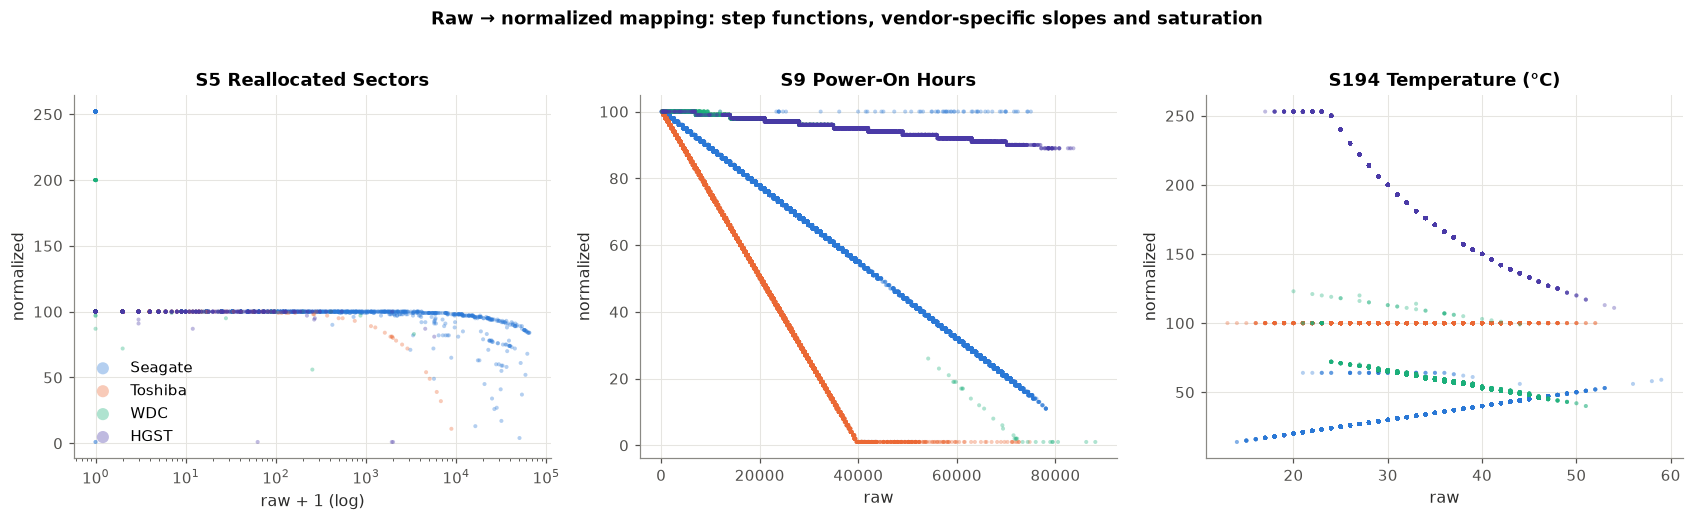

In [16]:
# 3.2 The raw → normalized mapping, coloured by vendor
samp = train.sample(40000, random_state=7)
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
for ax, i, xlog in zip(axes, [5, 9, 194], [True, False, False]):
    for v in ["Seagate", "Toshiba", "WDC", "HGST"]:
        s = samp[samp.vendor == v]
        xr = s[f"smart_{i}_raw_last"] + (1 if xlog else 0)
        ax.scatter(xr, s[f"smart_{i}_normalized_last"], s=7, alpha=0.35, color=VENDOR_COL[v], label=v, edgecolors="none")
    if xlog: ax.set_xscale("log"); ax.set_xlabel("raw + 1 (log)")
    else: ax.set_xlabel("raw")
    ax.set_ylabel("normalized"); ax.set_title(sname(i))
axes[0].legend(markerscale=3, loc="lower left")
fig.suptitle("Raw → normalized mapping: step functions, vendor-specific slopes and saturation", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

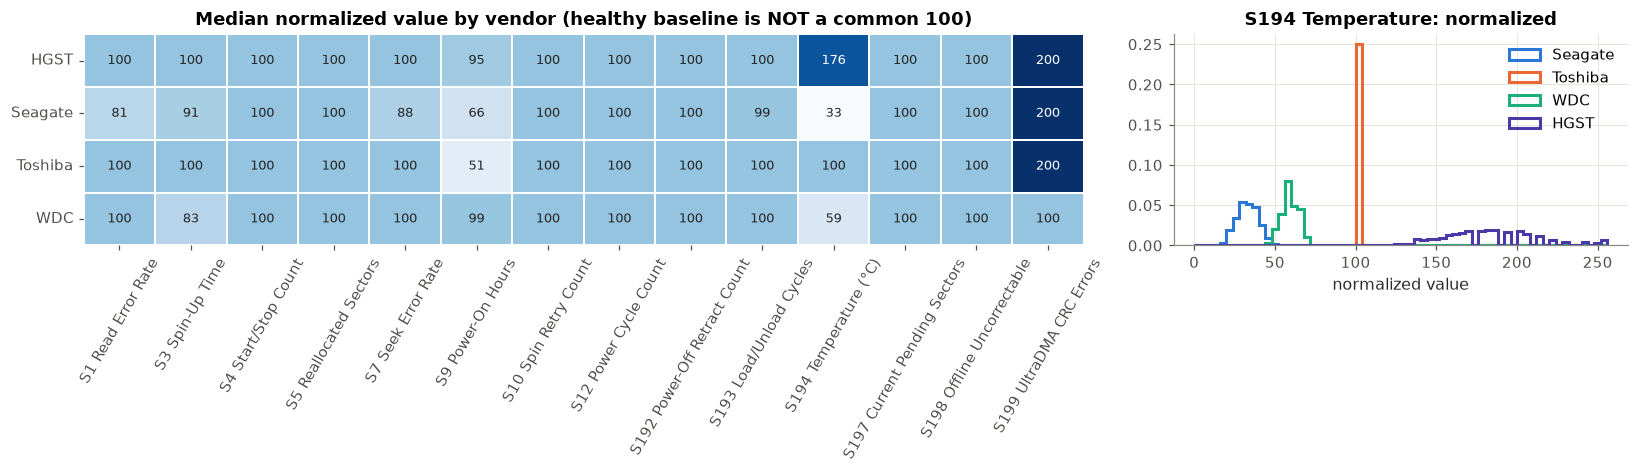

In [18]:
# 3.3 Vendor dependence: the same "normalized" score means different things per manufacturer
vend = train[train.vendor != "Other"]
med = vend.groupby("vendor")[[f"smart_{i}_normalized_last" for i in SMART_IDS]].median()
med.columns = [sname(i) for i in SMART_IDS]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [2.2, 1]})
sns.heatmap(med, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=axes[0], linewidths=1, linecolor="white", annot_kws={"fontsize": 8.5})
axes[0].set_title("Median normalized value by vendor (healthy baseline is NOT a common 100)"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=60); axes[0].tick_params(axis="y", rotation=0); axes[0].set_ylabel("")

for v in ["Seagate", "Toshiba", "WDC", "HGST"]:
    s = vend[vend.vendor == v]
    axes[1].hist(s.smart_194_normalized_last, bins=np.arange(0, 260, 4), histtype="step", lw=2, color=VENDOR_COL[v], label=v, density=True)
axes[1].set_title("S194 Temperature: normalized"); axes[1].set_xlabel("normalized value"); axes[1].legend()
plt.tight_layout(); plt.show()



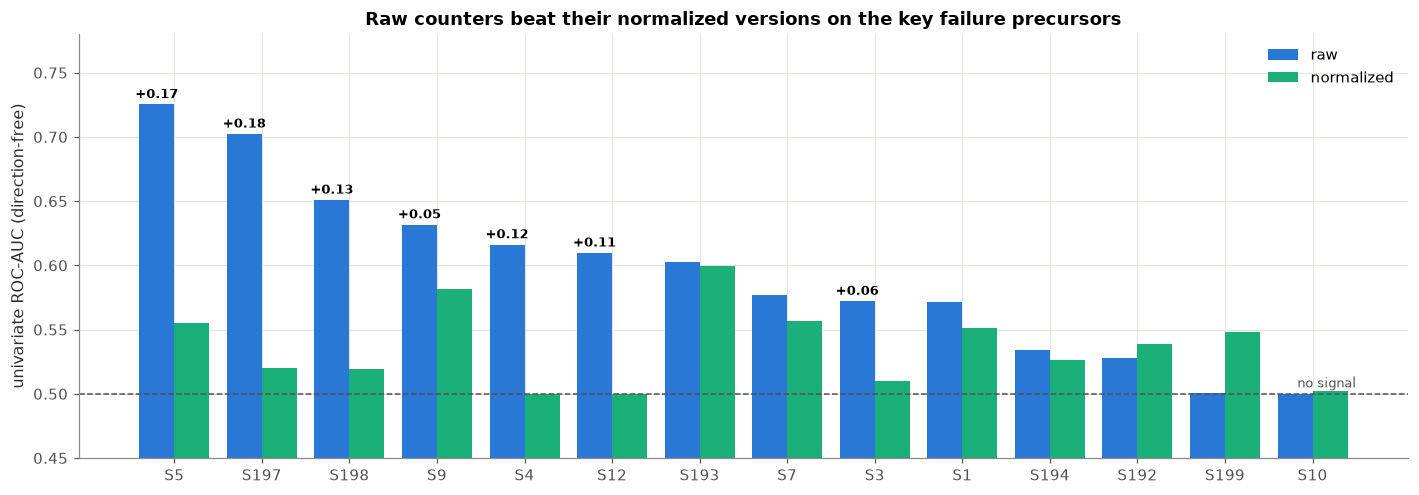

,AUC raw,AUC normalized,Δ (raw − norm),within-vendor AUC raw,within-vendor AUC normalized
attribute,,,,,
S5 Reallocated Sectors,0.725,0.555,0.170,0.696,0.546
S197 Current Pending Sectors,0.702,0.520,0.183,0.696,0.517
S198 Offline Uncorrectable,0.651,0.519,0.132,0.626,0.515
S9 Power-On Hours,0.632,0.581,0.050,0.578,0.579
S4 Start/Stop Count,0.616,0.500,0.116,0.608,0.500
S12 Power Cycle Count,0.610,0.500,0.110,0.602,0.500
S193 Load/Unload Cycles,0.602,0.599,0.003,0.582,0.545
S7 Seek Error Rate,0.577,0.556,0.021,0.525,0.514
S3 Spin-Up Time,0.572,0.510,0.062,0.525,0.559


In [19]:
# 3.4 Predictive power: univariate oriented ROC-AUC, raw vs normalized (pooled and within-vendor)
y = train.label.values
rows = []
for i in SMART_IDS:
    r = oriented_auc(y, train[f"smart_{i}_raw_last"].values.astype(float))
    n = oriented_auc(y, train[f"smart_{i}_normalized_last"].values.astype(float))
    # within-vendor AUC (weighted by vendor size) removes vendor-baseline effects
    wr, wn, ww = [], [], []
    for v, g in train[train.vendor != "Other"].groupby("vendor"):
        if g.label.sum() < 50: continue
        wr.append(oriented_auc(g.label.values, g[f"smart_{i}_raw_last"].values.astype(float)))
        wn.append(oriented_auc(g.label.values, g[f"smart_{i}_normalized_last"].values.astype(float)))
        ww.append(len(g))
    rows.append({"attribute": sname(i), "AUC raw": r, "AUC normalized": n, "Δ (raw − norm)": r - n,
                 "within-vendor AUC raw": np.average(wr, weights=ww), "within-vendor AUC normalized": np.average(wn, weights=ww)})
auc = pd.DataFrame(rows).set_index("attribute").sort_values("AUC raw", ascending=False)

fig, ax = plt.subplots(figsize=(13, 4.6))
x = np.arange(len(auc)); w = 0.4
ax.bar(x - w/2, auc["AUC raw"], w, color=SERIES[0], label="raw")
ax.bar(x + w/2, auc["AUC normalized"], w, color=SERIES[2], label="normalized")
ax.axhline(0.5, color="#52514e", lw=1, ls="--"); ax.text(len(auc) - 0.5, 0.505, "no signal", ha="right", fontsize=8.5, color="#52514e")
ax.set_ylim(0.45, 0.78); ax.set_xticks(x, [s.split(" ", 1)[0] for s in auc.index]); ax.set_ylabel("univariate ROC-AUC (direction-free)")
ax.set_title("Raw counters beat their normalized versions on the key failure precursors"); ax.legend()
for xi, (a, b) in enumerate(zip(auc["AUC raw"], auc["AUC normalized"])):
    if a - b > 0.05: ax.annotate(f"+{a-b:.2f}", (xi - w/2, a + 0.005), ha="center", fontsize=8.5, fontweight="bold")
plt.tight_layout(); plt.show()
display(auc.style.format("{:.3f}").background_gradient(subset=["Δ (raw − norm)"], cmap=DIVERGING, vmin=-0.2, vmax=0.2))


,skew raw,skew z-score,skew log1p,kurtosis raw,kurtosis log1p,AUC raw,AUC log1p,max |z| (outlier scale),share exactly 0
feature,,,,,,,,,
smart_5_raw_last,21.264,21.264,6.104,513.452,41.232,0.725,0.725,32.651,0.945
smart_197_raw_last,283.549,283.549,8.332,"92,135.500",80.372,0.702,0.702,347.107,0.969
smart_9_raw_last,0.671,0.671,-1.442,-0.432,2.908,0.632,0.632,3.447,0.000
smart_193_raw_last,5.273,5.273,-0.067,61.802,-0.152,0.602,0.602,31.726,0.000
smart_7_raw_last,410.745,410.745,0.323,"169,065.488",-1.866,0.577,0.577,411.638,0.574
smart_1_raw_last,1.175,1.175,0.310,-0.064,-1.885,0.572,0.572,9.015,0.571


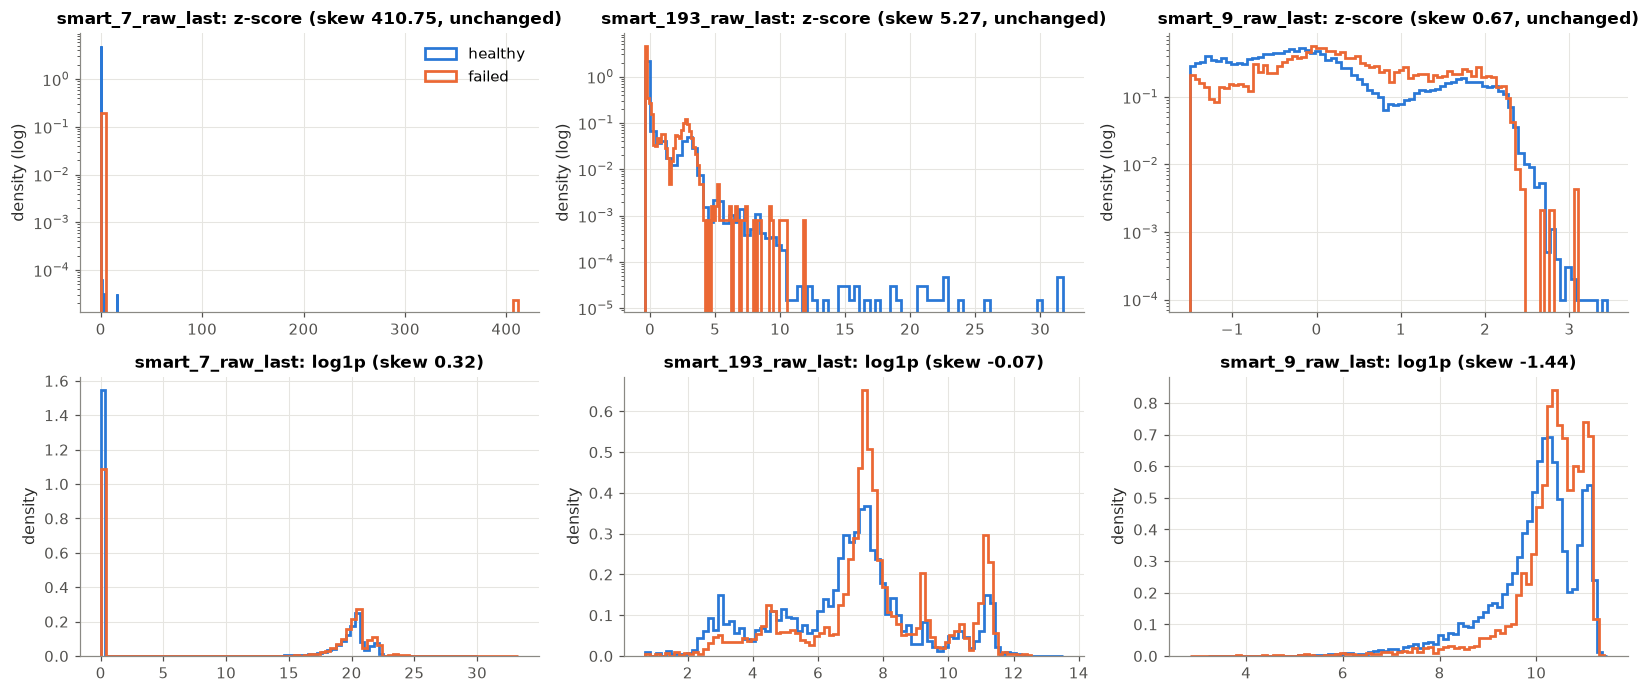

In [19]:
# 4.5 Statistical normalization: what log1p and z-scaling do (and don't do)
feat = ["smart_5_raw_last", "smart_197_raw_last", "smart_9_raw_last", "smart_193_raw_last", "smart_7_raw_last", "smart_1_raw_last"]
rows = []
for c in feat:
    x = train[c].dropna().astype(float)
    z = (x - x.mean()) / x.std()
    lg = np.log1p(x.clip(lower=0))
    rows.append({"feature": c, "skew raw": stats.skew(x), "skew z-score": stats.skew(z), "skew log1p": stats.skew(lg),
                 "kurtosis raw": stats.kurtosis(x), "kurtosis log1p": stats.kurtosis(lg),
                 "AUC raw": oriented_auc(train.loc[x.index, "label"].values, x.values),
                 "AUC log1p": oriented_auc(train.loc[x.index, "label"].values, lg.values),
                 "max |z| (outlier scale)": np.abs(z).max(), "share exactly 0": (x == 0).mean()})
tr = pd.DataFrame(rows).set_index("feature")
display(tr.style.format("{:,.3f}"))

fig, axes = plt.subplots(2, 3, figsize=(15, 6.4))
for j, c in enumerate(["smart_7_raw_last", "smart_193_raw_last", "smart_9_raw_last"]):
    x = train[c].dropna()
    for lab, col, nm in [(0, HEALTHY, "healthy"), (1, FAILED, "failed")]:
        xs = x[train.loc[x.index, "label"] == lab]
        axes[0, j].hist((xs - x.mean()) / x.std(), bins=80, color=col, histtype="step", lw=1.8, density=True, label=nm)
        axes[1, j].hist(np.log1p(xs.clip(lower=0)), bins=80, color=col, histtype="step", lw=1.8, density=True, label=nm)
    sk0, sk1 = stats.skew(x), stats.skew(np.log1p(x.clip(lower=0)))
    axes[0, j].set_title(f"{c}: z-score (skew {sk0:.2f}, unchanged)", fontsize=11); axes[1, j].set_title(f"{c}: log1p (skew {sk1:.2f})", fontsize=11)
    axes[0, j].set_yscale("log"); axes[0, j].set_ylabel("density (log)"); axes[1, j].set_ylabel("density")
axes[0, 0].legend(); plt.tight_layout(); plt.show()

**Interpretation: vendor normalization usually destroys signal.**
todo

---
## 7. Statistical Analysis 4: Correlation, Redundancy, Degradation and Information Ranking

**What this shows:**
 todo

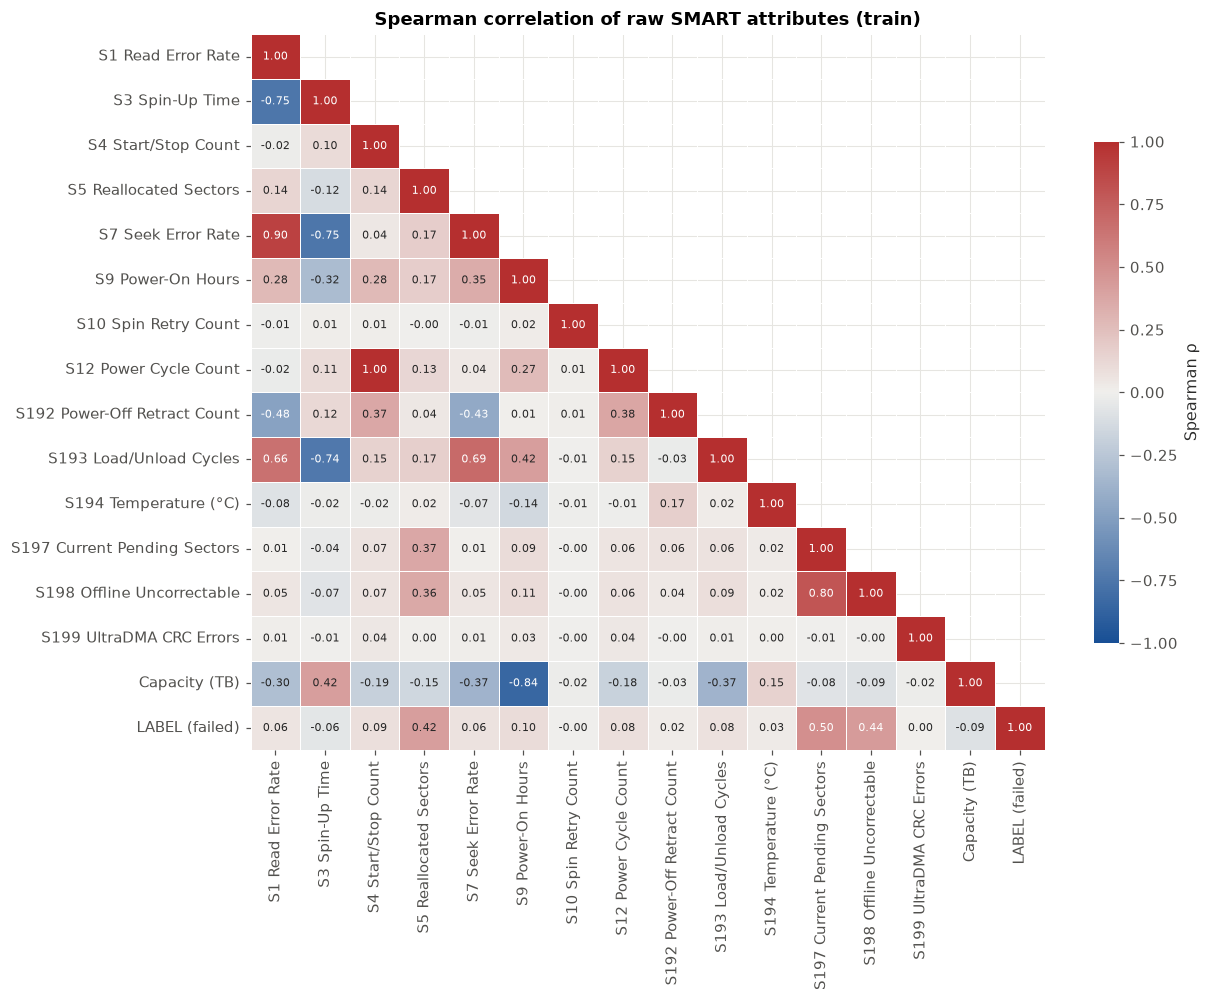

Most redundant pairs (|ρ| ≥ 0.6):


feature A,feature B,ρ
S4 Start/Stop Count,S12 Power Cycle Count,+0.997
S1 Read Error Rate,S7 Seek Error Rate,+0.901
S9 Power-On Hours,Capacity (TB),-0.845
S197 Current Pending Sectors,S198 Offline Uncorrectable,+0.803
S3 Spin-Up Time,S7 Seek Error Rate,-0.755
S1 Read Error Rate,S3 Spin-Up Time,-0.754
S3 Spin-Up Time,S193 Load/Unload Cycles,-0.736
S7 Seek Error Rate,S193 Load/Unload Cycles,+0.692
S1 Read Error Rate,S193 Load/Unload Cycles,+0.656


In [20]:
cols = [f"smart_{i}_raw_last" for i in SMART_IDS] + ["capacity_tb", "label"]
corr = train[cols].corr(method="spearman")
corr.index = corr.columns = [sname(i) for i in SMART_IDS] + ["Capacity (TB)", "LABEL (failed)"]
mask = np.triu(np.ones_like(corr, bool), k=1)
fig, ax = plt.subplots(figsize=(11.5, 9.2))
sns.heatmap(corr, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f", annot_kws={"fontsize": 7.5},
            linewidths=0.6, linecolor="white", cbar_kws={"shrink": 0.7, "label": "Spearman ρ"}, ax=ax)
ax.set_title("Spearman correlation of raw SMART attributes (train)")
plt.tight_layout(); plt.show()

pairs = (corr.where(~np.tril(np.ones_like(corr, bool))).stack().rename("ρ").reset_index()
         .rename(columns={"level_0": "feature A", "level_1": "feature B"}))
pairs = pairs[~pairs["feature B"].str.startswith("LABEL")].reindex(pairs["ρ"].abs().sort_values(ascending=False).index)
print("Most redundant pairs (|ρ| ≥ 0.6):")
display(pairs[pairs["ρ"].abs() >= 0.6].head(12).style.format({"ρ": "{:+.3f}"}).hide(axis="index"))

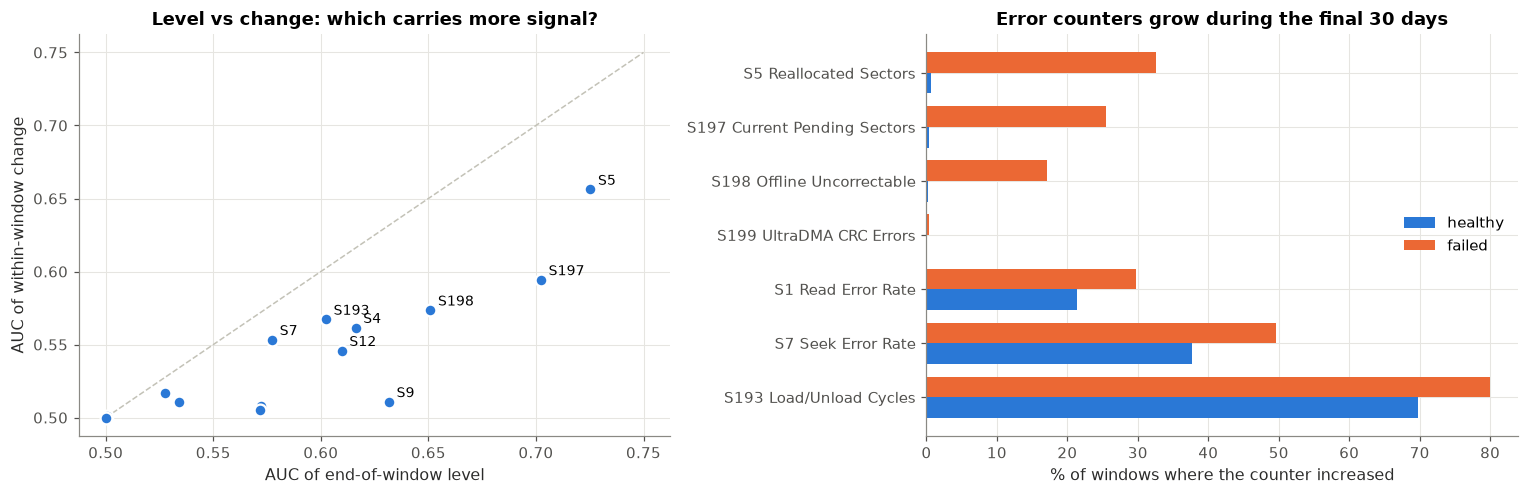

,AUC last (level),AUC delta (change),% failed with increase,% healthy with increase,lift (fail/healthy)
attribute,,,,,
S5 Reallocated Sectors,0.725,0.656,32.6%,0.6%,54.1×
S197 Current Pending Sectors,0.702,0.594,25.4%,0.3%,81.9×
S198 Offline Uncorrectable,0.651,0.574,17.1%,0.2%,97.1×
S9 Power-On Hours,0.632,0.511,99.9%,99.9%,1.0×
S4 Start/Stop Count,0.616,0.562,20.9%,8.8%,2.4×
S12 Power Cycle Count,0.610,0.546,17.8%,8.8%,2.0×
S193 Load/Unload Cycles,0.602,0.567,80.0%,69.8%,1.1×
S7 Seek Error Rate,0.577,0.553,49.6%,37.6%,1.3×
S3 Spin-Up Time,0.572,0.508,3.8%,1.2%,3.1×


In [ ]:
# (b) Level vs change: is degradation *during* the window informative?
y = train.label.values
rows = []
for i in SMART_IDS:
    L = train[f"smart_{i}_raw_last"].values.astype(float)
    D = train[f"smart_{i}_raw_delta"].values.astype(float)
    inc_f = (train.loc[train.label == 1, f"smart_{i}_raw_delta"] > 0).mean()
    inc_h = (train.loc[train.label == 0, f"smart_{i}_raw_delta"] > 0).mean()
    rows.append({"attribute": sname(i), "AUC last (level)": oriented_auc(y, L), "AUC delta (change)": oriented_auc(y, D),
                 "% failed with increase": inc_f, "% healthy with increase": inc_h, "lift (fail/healthy)": inc_f / max(inc_h, 1e-6)})
lvd = pd.DataFrame(rows).set_index("attribute").sort_values("AUC last (level)", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ax = axes[0]
ax.scatter(lvd["AUC last (level)"], lvd["AUC delta (change)"], s=60, color=SERIES[0], edgecolors="white", linewidths=1.5, zorder=3)
for lab, r in lvd.iterrows():
    if r["AUC last (level)"] > 0.58 or r["AUC delta (change)"] > 0.54:
        ax.annotate(lab.split(" ", 1)[0], (r["AUC last (level)"], r["AUC delta (change)"]), xytext=(5, 3), textcoords="offset points", fontsize=9)
ax.plot([0.5, 0.75], [0.5, 0.75], ls="--", color="#c3c2b7", lw=1)
ax.set_xlabel("AUC of end-of-window level"); ax.set_ylabel("AUC of within-window change"); ax.set_title("Level vs change: which carries more signal?")

sub = lvd.loc[[sname(i) for i in [5, 197, 198, 199, 1, 7, 193]]]
yy = np.arange(len(sub)); h = 0.38
axes[1].barh(yy + h/2, sub["% healthy with increase"] * 100, h, color=HEALTHY, label="healthy")
axes[1].barh(yy - h/2, sub["% failed with increase"] * 100, h, color=FAILED, label="failed")
axes[1].set_yticks(yy, sub.index); axes[1].invert_yaxis(); axes[1].set_xlabel("% of windows where the counter increased")
axes[1].set_title("Error counters grow during the final 30 days"); axes[1].legend(loc="center right")
plt.tight_layout(); plt.show()
display(lvd.style.format({"AUC last (level)": "{:.3f}", "AUC delta (change)": "{:.3f}", "% failed with increase": "{:.1%}",
                          "% healthy with increase": "{:.1%}", "lift (fail/healthy)": "{:.1f}×"}))

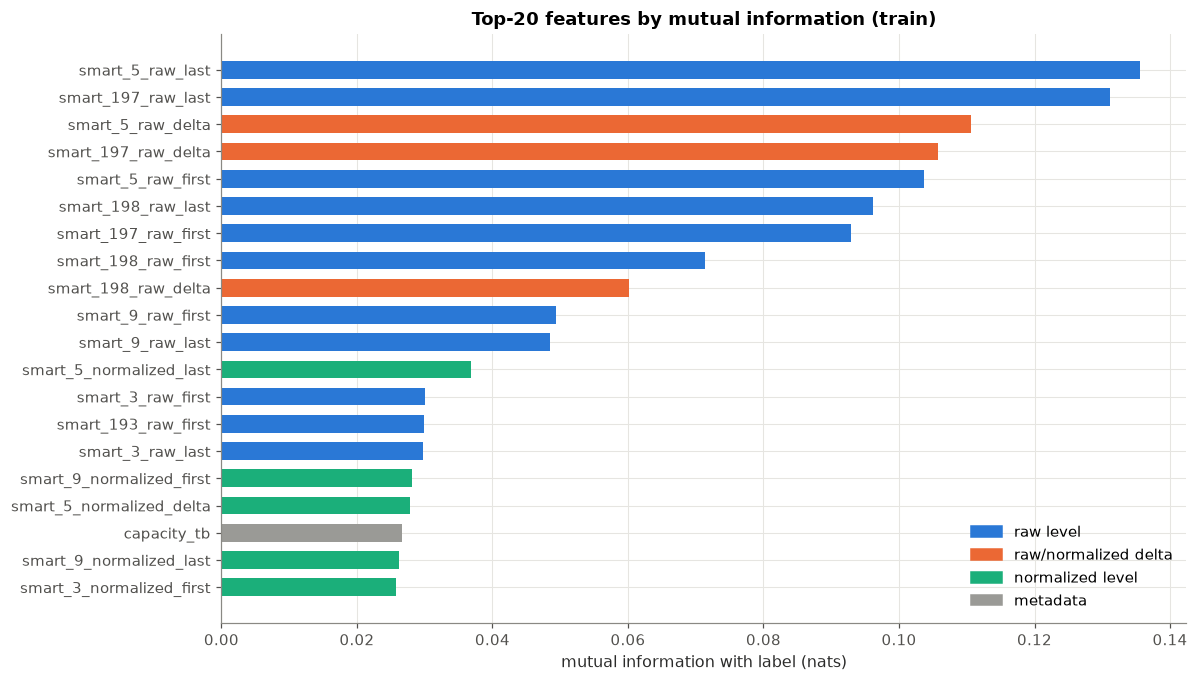

,sum,mean,max
metadata,0.0460,0.0230,0.0266
normalized,0.4715,0.0112,0.0369
raw,1.3510,0.0322,0.1356


In [22]:
# (c) Mutual information ranking over every SMART feature + age + capacity
smart_cols = [c for c in train.columns if c.startswith("smart_")]
Xmi = train[smart_cols + ["capacity_tb", "drive_days_to_date"]].copy()
Xmi = Xmi.fillna(Xmi.median())
samp_idx = train.groupby("label", group_keys=False).apply(lambda g: g.sample(min(len(g), 25000), random_state=1)).index
mi = mutual_info_classif(Xmi.loc[samp_idx], train.loc[samp_idx, "label"], random_state=0, n_neighbors=5)
mi = pd.Series(mi, index=Xmi.columns).sort_values(ascending=False)

top = mi.head(20)[::-1]
def fam_col(c):
    if "_normalized_" in c: return SERIES[2]
    if c.endswith("_delta"): return SERIES[1]
    if "_raw_" in c: return SERIES[0]
    return "#9a9a96"
fig, ax = plt.subplots(figsize=(11, 6.3))
ax.barh(top.index, top.values, color=[fam_col(c) for c in top.index], height=0.65)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in [SERIES[0], SERIES[1], SERIES[2], "#9a9a96"]]
ax.legend(handles, ["raw level", "raw/normalized delta", "normalized level", "metadata"], loc="lower right")
ax.set_xlabel("mutual information with label (nats)"); ax.set_title("Top-20 features by mutual information (train)")
plt.tight_layout(); plt.show()

fam_mi = mi.groupby(lambda c: "normalized" if "_normalized_" in c else "raw" if "_raw_" in c else "metadata").agg(["sum", "mean", "max"])
display(fam_mi.style.format("{:.4f}"))

**Interpretation.**
 todo

---
## 10. Conclusions: What the Data Tells Us

### Dataset
todo